In [49]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

In [50]:
# Load AOI data
df = pd.read_csv('raw/AOITotalFixation.tsv', sep='\t')
print(f"Loaded {len(df)} rows with {len(df.columns)} columns")

print(f"Found {len(fixation_cols)} AOI fixation columns")

# Get all AOI fixation columnsfixation_cols = [col for col in df.columns if col.startswith('Number_of_fixations.')]

Loaded 594 rows with 8616 columns
Found 1230 AOI fixation columns


## Fixation Analysis: Oscuro vs Claro

This analysis compares total fixations between "Oscuro" (dark mode) and "Claro" (light mode) conditions for:

- Overall comparison (all scenarios combined)- Mochila scenario only
- Patata scenario only

In [51]:
# Filter single media only (no combined rows)
mask = df['Media'].str.contains('Oscuro|Claro', na=False) & ~df['Media'].str.contains(',', na=False)
df_filtered = df[mask].copy()
df_filtered['Condition'] = df_filtered['Media'].str.extract('(Oscuro|Claro)')[0]
df_filtered['Scenario'] = df_filtered['Media'].str.extract('(Patata|Mochila)')[0]

# Sum all AOI fixations per row for overall comparison
df_filtered['Total_AOI_Fixations'] = df_filtered[fixation_cols].sum(axis=1)

# Overall comparison
overall_oscuro = df_filtered[df_filtered['Condition'] == 'Oscuro']['Total_AOI_Fixations']
overall_claro = df_filtered[df_filtered['Condition'] == 'Claro']['Total_AOI_Fixations']
t_overall, p_overall = stats.ttest_ind(overall_oscuro, overall_claro)

# Patata scenario
patata_data = df_filtered[df_filtered['Scenario'] == 'Patata']
patata_oscuro = patata_data[patata_data['Condition'] == 'Oscuro']['Total_AOI_Fixations']
patata_claro = patata_data[patata_data['Condition'] == 'Claro']['Total_AOI_Fixations']
t_patata, p_patata = stats.ttest_ind(patata_oscuro, patata_claro)

# Mochila scenario
mochila_data = df_filtered[df_filtered['Scenario'] == 'Mochila']
mochila_oscuro = mochila_data[mochila_data['Condition'] == 'Oscuro']['Total_AOI_Fixations']
mochila_claro = mochila_data[mochila_data['Condition'] == 'Claro']['Total_AOI_Fixations']
t_mochila, p_mochila = stats.ttest_ind(mochila_oscuro, mochila_claro)

# Print results
print("=" * 70)
print("OVERALL (All Scenarios)")
print(f"Oscuro: {overall_oscuro.sum()} total ({overall_oscuro.mean():.1f} mean, n={len(overall_oscuro)})")
print(f"Claro: {overall_claro.sum()} total ({overall_claro.mean():.1f} mean, n={len(overall_claro)})")
print(f"t-test: t={t_overall:.3f}, p={p_overall:.4f} ({'Significant' if p_overall < 0.05 else 'Not Significant'})")

print("\n" + "=" * 70)
print("PATATA SCENARIO")
print(f"Oscuro: {patata_oscuro.sum()} total ({patata_oscuro.mean():.1f} mean, n={len(patata_oscuro)})")
print(f"Claro: {patata_claro.sum()} total ({patata_claro.mean():.1f} mean, n={len(patata_claro)})")
print(f"t-test: t={t_patata:.3f}, p={p_patata:.4f} ({'Significant' if p_patata < 0.05 else 'Not Significant'})")

print("\n" + "=" * 70)
print("MOCHILA SCENARIO")
print(f"Oscuro: {mochila_oscuro.sum()} total ({mochila_oscuro.mean():.1f} mean, n={len(mochila_oscuro)})")
print(f"Claro: {mochila_claro.sum()} total ({mochila_claro.mean():.1f} mean, n={len(mochila_claro)})")
print(f"t-test: t={t_mochila:.3f}, p={p_mochila:.4f} ({'Significant' if p_mochila < 0.05 else 'Not Significant'})")
print("=" * 70)

OVERALL (All Scenarios)
Oscuro: 4908.0 total (144.4 mean, n=34)
Claro: 4741.0 total (139.4 mean, n=34)
t-test: t=0.317, p=0.7522 (Not Significant)

PATATA SCENARIO
Oscuro: 1967.0 total (115.7 mean, n=17)
Claro: 2042.0 total (120.1 mean, n=17)
t-test: t=-0.279, p=0.7821 (Not Significant)

MOCHILA SCENARIO
Oscuro: 2941.0 total (173.0 mean, n=17)
Claro: 2699.0 total (158.8 mean, n=17)
t-test: t=0.586, p=0.5620 (Not Significant)


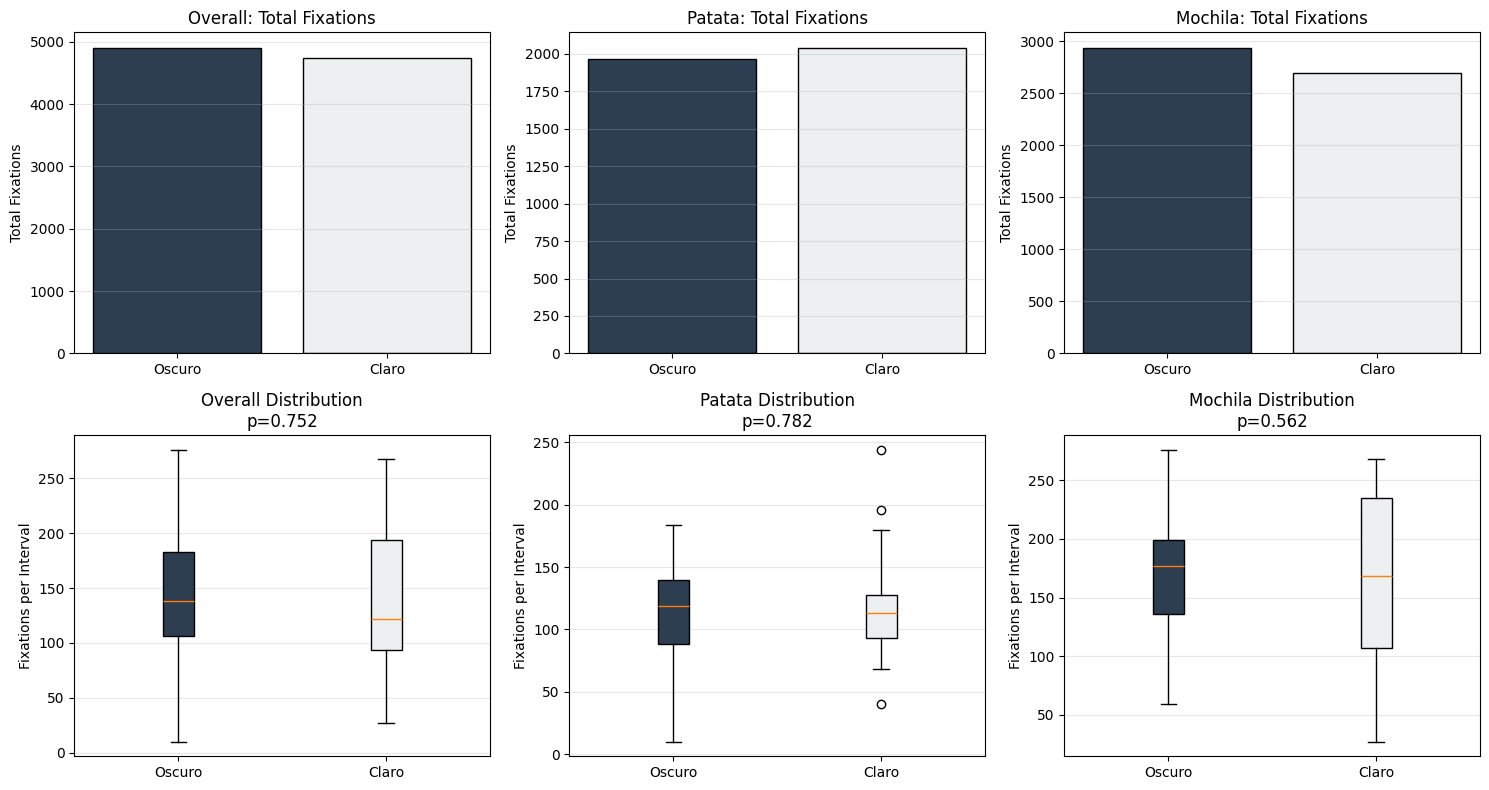

In [52]:
# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
colors = ['#2c3e50', '#ecf0f1']

# Row 1: Bar charts
for idx, (title, osc, cla) in enumerate([
    ('Overall', overall_oscuro, overall_claro),
    ('Patata', patata_oscuro, patata_claro),
    ('Mochila', mochila_oscuro, mochila_claro)
]):
    axes[0, idx].bar(['Oscuro', 'Claro'], [osc.sum(), cla.sum()], color=colors, edgecolor='black')
    axes[0, idx].set_ylabel('Total Fixations')
    axes[0, idx].set_title(f'{title}: Total Fixations')
    axes[0, idx].grid(axis='y', alpha=0.3)

# Row 2: Box plots
for idx, (title, osc, cla, t, p) in enumerate([
    ('Overall', overall_oscuro, overall_claro, t_overall, p_overall),
    ('Patata', patata_oscuro, patata_claro, t_patata, p_patata),
    ('Mochila', mochila_oscuro, mochila_claro, t_mochila, p_mochila)
]):
    bp = axes[1, idx].boxplot([osc, cla], tick_labels=['Oscuro', 'Claro'], patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    axes[1, idx].set_ylabel('Fixations per Interval')
    axes[1, idx].set_title(f'{title} Distribution\np={p:.3f}')
    axes[1, idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('output/fixation_comparison_all_scenarios.png', dpi=300, bbox_inches='tight')
plt.show()